# Bouncing Mass With NCP Contact

This notebook uses the NCP backend in `solve_nivp.ncp_contact`.

Important modeling note:
- The current NCP backend enforces unilateral **force** complementarity.
- It does **not** implement an impact restitution law with coefficient `e`.
- To get a rebound while staying honest about the model, this example uses a mass attached to a spring anchored above the floor. The floor contact is handled by NCP; the spring provides the lift-off after impact.

The comparison below keeps both NCP variants on the same problem:
- `fischer_burmeister` is the recommended default.
- `minimum_map` is included because it tends to stall right at contact onset on this setup.


In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

import solve_nivp
from solve_nivp import build_dynamic_ncp_contact

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=4, suppress=True)


In [2]:
def iteration_stats(result):
    its = result["iterations"]
    if its.size == 0:
        return {"max": 0, "mean": np.nan, "median": np.nan}
    return {
        "max": int(its.max()),
        "mean": float(its.mean()),
        "median": float(np.median(its)),
    }


def print_table(headers, rows):
    widths = [max(len(str(h)), *(len(str(row[i])) for row in rows)) for i, h in enumerate(headers)]
    fmt = " | ".join(f"{{:{w}}}" for w in widths)
    sep = "-+-".join("-" * w for w in widths)
    print(fmt.format(*headers))
    print(sep)
    for row in rows:
        print(fmt.format(*row))


def run_case(cs, *, method="backward_euler", t_span=(0.0, 0.30), h=0.005, max_iter=80):
    tic = time.time()
    t, y, h_hist, fk, info = solve_nivp.solve_nivp(
        fun=cs.rhs,
        t_span=t_span,
        y0=cs.y0,
        method=method,
        projection=cs.projection,
        solver="semismooth_newton",
        projection_opts={},
        solver_opts={
            "tol": 1.0e-10,
            "max_iter": max_iter,
            "globalization": "linesearch",
            "linear_solver": "splu",
            "rhs_jac": cs.rhs_jac,
        },
        adaptive=False,
        h0=h,
        integrator_opts=cs.integrator_opts,
        component_slices=cs.component_slices,
        A=cs.A,
        store_fk=False,
    )
    success = np.array([row[1] for row in info], dtype=bool)
    iterations = np.array([row[2] for row in info], dtype=int)
    solver_error = np.array([row[0] for row in info], dtype=float)
    return {
        "t": t,
        "y": y,
        "h": h_hist,
        "success": success,
        "iterations": iterations,
        "solver_error": solver_error,
        "success_all": bool(success.all()) if success.size else True,
        "elapsed": time.time() - tic,
    }


def rebound_count(result):
    v = result["y"][:, 0]
    return int(np.count_nonzero((v[:-1] < 0.0) & (v[1:] > 0.0)))


In [3]:
m = 1.0
k = 60.0
c = 0.1
q_anchor = 0.4
g = 9.81

A = np.diag([m, 1.0])
y0 = np.array([-2.0, 0.25], dtype=float)
t_span = (0.0, 0.30)
h = 0.005


def rhs(t, y):
    v, q = y
    return np.array([-k * (q - q_anchor) - c * v - m * g, v], dtype=float)


def gap(y, t):
    return np.array([y[1]], dtype=float)


def build_case(ncp_type="fischer_burmeister"):
    return build_dynamic_ncp_contact(
        A=A,
        rhs_smooth=rhs,
        y0=y0,
        contacts=[dict(vel_normal_idx=0, vel_tangential_idx=[], mu=0.0)],
        gap_func=gap,
        ncp_type=ncp_type,
    )


In [4]:
fb_cs = build_case("fischer_burmeister")
mm_cs = build_case("minimum_map")

fb = run_case(fb_cs, t_span=t_span, h=h)
mm = run_case(mm_cs, t_span=t_span, h=h)

rows = []
for label, cs, result in [
    ("minimum_map", mm_cs, mm),
    ("fischer_burmeister", fb_cs, fb),
]:
    stats = iteration_stats(result)
    rn = result["y"][:, cs.n_phys]
    rows.append((
        label,
        result["success_all"],
        int((rn > 1.0e-8).sum()),
        rebound_count(result),
        stats["max"],
        f"{stats['mean']:.2f}",
        f"{result['t'][-1]:.3f}",
        f"{result['y'][-1, 1]:.4f}",
    ))

print_table(
    [
        "ncp_type",
        "all steps converged",
        "contact steps",
        "rebounds",
        "max Newton iters",
        "mean Newton iters",
        "final t",
        "final gap",
    ],
    rows,
)

print("\nRecommended default for this example: fischer_burmeister")
print("Reason: it crosses the first contact and rebound; minimum_map stalls at contact onset on this setup.")


ncp_type           | all steps converged | contact steps | rebounds | max Newton iters | mean Newton iters | final t | final gap
-------------------+---------------------+---------------+----------+------------------+-------------------+---------+----------
minimum_map        |                   0 |             0 |        0 |                2 | 2.00              | 0.165   | 0.0012   
fischer_burmeister |                   1 |             2 |        1 |               15 | 2.45              | 0.300   | 0.1044   

Recommended default for this example: fischer_burmeister
Reason: it crosses the first contact and rebound; minimum_map stalls at contact onset on this setup.


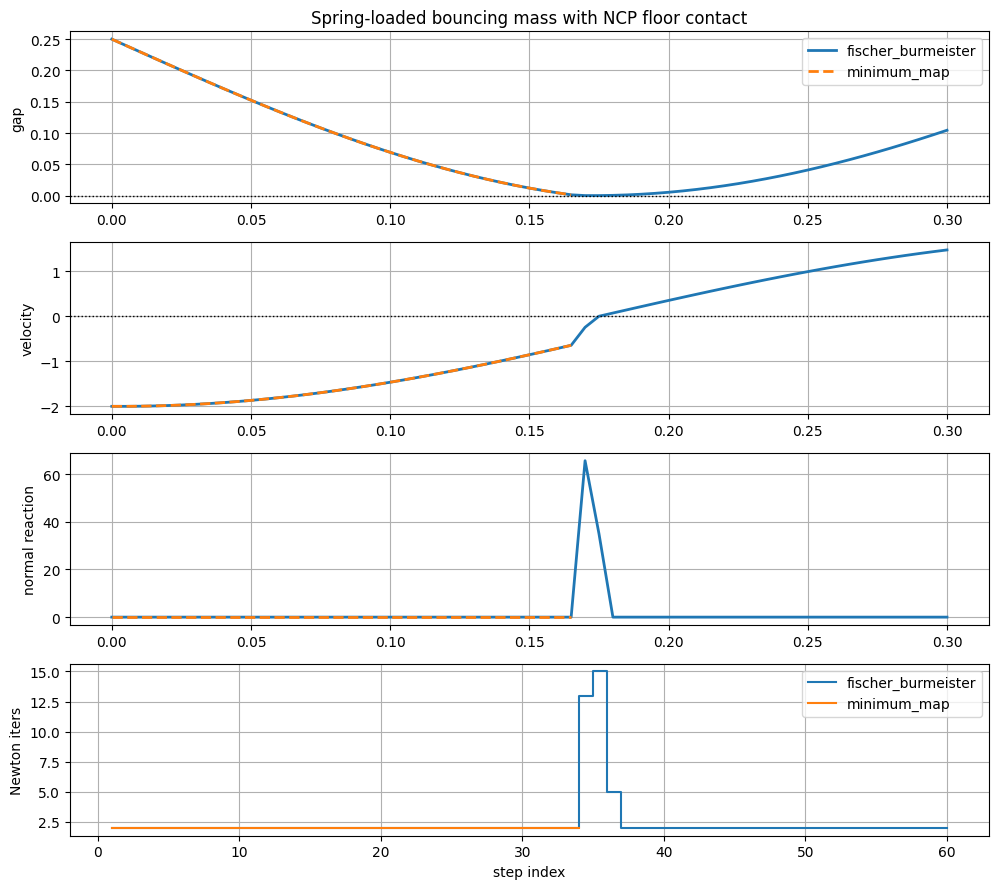

In [5]:
t_fb = fb["t"]
y_fb = fb["y"]
rn_fb = y_fb[:, fb_cs.n_phys]

t_mm = mm["t"]
y_mm = mm["y"]
rn_mm = y_mm[:, mm_cs.n_phys]

fig, axs = plt.subplots(4, 1, figsize=(10, 9), sharex=False)

axs[0].plot(t_fb, y_fb[:, 1], lw=2, label="fischer_burmeister")
axs[0].plot(t_mm, y_mm[:, 1], "--", lw=2, label="minimum_map")
axs[0].axhline(0.0, color="k", ls=":", lw=1)
axs[0].set_ylabel("gap")
axs[0].set_title("Spring-loaded bouncing mass with NCP floor contact")
axs[0].legend()

axs[1].plot(t_fb, y_fb[:, 0], lw=2, label="fischer_burmeister")
axs[1].plot(t_mm, y_mm[:, 0], "--", lw=2, label="minimum_map")
axs[1].axhline(0.0, color="k", ls=":", lw=1)
axs[1].set_ylabel("velocity")

axs[2].plot(t_fb, rn_fb, lw=2, label="fischer_burmeister")
axs[2].plot(t_mm, rn_mm, "--", lw=2, label="minimum_map")
axs[2].set_ylabel("normal reaction")

axs[3].step(np.arange(1, fb["iterations"].size + 1), fb["iterations"], where="post", lw=1.5, label="fischer_burmeister")
axs[3].step(np.arange(1, mm["iterations"].size + 1), mm["iterations"], where="post", lw=1.5, label="minimum_map")
axs[3].set_ylabel("Newton iters")
axs[3].set_xlabel("step index")
axs[3].legend()

plt.tight_layout()
plt.show()


In [6]:
fb_contact = np.flatnonzero(rn_fb > 1.0e-8)
if fb_contact.size:
    print(f"Fischer-Burmeister first active contact appears near t = {t_fb[fb_contact[0]]:.6f} s.")

print(f"Minimum-map run stopped at t = {t_mm[-1]:.6f} s.")
print("If you need a restitution coefficient e, the current NCP backend is the wrong contact law for that model.")
print("For restitutional bouncing, use the Moreau / SOC impact path or an event-driven impact model instead.")


Fischer-Burmeister first active contact appears near t = 0.170000 s.
Minimum-map run stopped at t = 0.165000 s.
If you need a restitution coefficient e, the current NCP backend is the wrong contact law for that model.
For restitutional bouncing, use the Moreau / SOC impact path or an event-driven impact model instead.
